# TCRB Entrypoint: Core Outcomes

This notebook is the single entrypoint for running and observing core project outcomes:

1. Reliability benchmarking under controlled failures
2. Reproducible evaluation with interpretable signal checks

Running this notebook executes the core flow (multi-seed, delta, matrix, study-gate) and renders analysis visuals.

In [7]:
from __future__ import annotations

import json
import os
import subprocess
import sys
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt


def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / 'pyproject.toml').exists() and (candidate / 'src').exists():
            return candidate
    raise RuntimeError('Repository root not found from current kernel working directory.')


REPO_ROOT = find_repo_root(Path.cwd())
os.chdir(REPO_ROOT)

RUN_TAG = datetime.utcnow().strftime('entrypoint-core-%Y%m%d-%H%M%S')
BASE_LABEL = f'{RUN_TAG}-base-ms'
COMPARISON_LABEL = f'{RUN_TAG}-comparison-ms'
DELTA_DIR = REPO_ROOT / 'runs' / f'{RUN_TAG}-delta'
MATRIX_LABEL = f'{RUN_TAG}-matrix'
STUDY_DIR = REPO_ROOT / 'runs' / f'{RUN_TAG}-study-gate'

print('Repo root:', REPO_ROOT)
print('Run tag:', RUN_TAG)

Repo root: /Users/aaliyan/aaliyan/tool-calling-reliability-benchmark
Run tag: entrypoint-core-20260403-192104


In [8]:
def run_cmd(cmd: list[str]) -> None:
    env = os.environ.copy()
    env['PYTHONPATH'] = str(REPO_ROOT / 'src') + (os.pathsep + env['PYTHONPATH'] if env.get('PYTHONPATH') else '')
    print('Running:', ' '.join(cmd))
    proc = subprocess.Popen(
        cmd,
        cwd=str(REPO_ROOT),
        env=env,
        text=True,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
    )
    assert proc.stdout is not None
    for line in proc.stdout:
        print(line, end='')
    rc = proc.wait()
    if rc != 0:
        raise RuntimeError(f"Command failed with exit code {rc}: {' '.join(cmd)}")

run_cmd([
    sys.executable, '-m', 'tcrb', 'multi-seed',
    '--config', 'configs/baseline.json',
    '--workload', 'workloads/sample_tasks.json',
    '--seeds', '1,2,3',
    '--planner-config', 'configs/planners/policy_native.json',
    '--label', BASE_LABEL,
] )

run_cmd([
    sys.executable, '-m', 'tcrb', 'multi-seed',
    '--config', 'configs/baseline.json',
    '--workload', 'workloads/sample_tasks.json',
    '--seeds', '1,2,3',
    '--planner-config', 'configs/planners/heuristic.json',
    '--label', COMPARISON_LABEL,
] )

run_cmd([
    sys.executable, '-m', 'tcrb', 'eval-delta',
    '--base-run', f'runs/{BASE_LABEL}/multi_seed.json',
    '--comparison-run', f'runs/{COMPARISON_LABEL}/multi_seed.json',
    '--output-json', f'runs/{RUN_TAG}-delta/delta-ms.json',
    '--output-report', f'runs/{RUN_TAG}-delta/delta-ms.md',
] )

run_cmd([
    sys.executable, 'scripts/run_transfer_matrix.py',
    '--manifest', 'workloads/enriched/manifest.json',
    '--config', 'configs/baseline.json',
    '--base-planner-config', 'configs/planners/policy_native.json',
    '--comparison-planner-config', 'configs/planners/stochastic_lowhalluc.json',
    '--target-toolset', 'customer_support',
    '--max-tasks', '0',
    '--label', MATRIX_LABEL,
] )

run_cmd([
    sys.executable, '-m', 'tcrb', 'study-gate',
    '--base-run', f'runs/{BASE_LABEL}/multi_seed.json',
    '--comparison-run', f'runs/{COMPARISON_LABEL}/multi_seed.json',
    '--matrix-json', f'runs/{MATRIX_LABEL}/matrix.json',
    '--require-matrix-signal',
    '--output-json', f'runs/{RUN_TAG}-study-gate/study_gate.json',
    '--output-report', f'runs/{RUN_TAG}-study-gate/study_gate.md',
] )

print('Core pipeline run completed.')

Running: /Users/aaliyan/aaliyan/tool-calling-reliability-benchmark/.venv/bin/python -m tcrb multi-seed --config configs/baseline.json --workload workloads/sample_tasks.json --seeds 1,2,3 --planner-config configs/planners/policy_native.json --label entrypoint-core-20260403-192104-base-ms
Planner: policy_native
Wrote multi-seed results: runs/entrypoint-core-20260403-192104-base-ms/multi_seed.json
Wrote multi-seed summary: runs/entrypoint-core-20260403-192104-base-ms/multi_seed_summary.md
Running: /Users/aaliyan/aaliyan/tool-calling-reliability-benchmark/.venv/bin/python -m tcrb multi-seed --config configs/baseline.json --workload workloads/sample_tasks.json --seeds 1,2,3 --planner-config configs/planners/heuristic.json --label entrypoint-core-20260403-192104-comparison-ms
Planner: heuristic_v1
Wrote multi-seed results: runs/entrypoint-core-20260403-192104-comparison-ms/multi_seed.json
Wrote multi-seed summary: runs/entrypoint-core-20260403-192104-comparison-ms/multi_seed_summary.md
Runni

In [9]:
base_path = REPO_ROOT / 'runs' / BASE_LABEL / 'multi_seed.json'
comparison_path = REPO_ROOT / 'runs' / COMPARISON_LABEL / 'multi_seed.json'
delta_json_path = DELTA_DIR / 'delta-ms.json'
delta_md_path = DELTA_DIR / 'delta-ms.md'
matrix_json_path = REPO_ROOT / 'runs' / MATRIX_LABEL / 'matrix.json'
matrix_md_path = REPO_ROOT / 'runs' / MATRIX_LABEL / 'matrix_summary.md'
study_json_path = STUDY_DIR / 'study_gate.json'
study_md_path = STUDY_DIR / 'study_gate.md'

paths = [
    base_path, comparison_path, delta_json_path, delta_md_path,
    matrix_json_path, matrix_md_path, study_json_path, study_md_path,
]

print('Artifacts:')
for p in paths:
    print('-', p.relative_to(REPO_ROOT), 'exists=' + str(p.exists()))

delta_payload = json.loads(delta_json_path.read_text(encoding='utf-8'))
matrix_payload = json.loads(matrix_json_path.read_text(encoding='utf-8'))
study_payload = json.loads(study_json_path.read_text(encoding='utf-8'))

target_rows = delta_payload.get('target', {}).get('policies', [])
mean_success_delta = 0.0
mean_invalid_delta = 0.0
if target_rows:
    success_vals = [float(r['delta']['task_success_rate']) for r in target_rows if r.get('delta', {}).get('task_success_rate') is not None]
    invalid_vals = [float(r['delta']['invalid_tool_call_rate']) for r in target_rows if r.get('delta', {}).get('invalid_tool_call_rate') is not None]
    mean_success_delta = sum(success_vals) / len(success_vals) if success_vals else 0.0
    mean_invalid_delta = sum(invalid_vals) / len(invalid_vals) if invalid_vals else 0.0

print('\nOutcome summary:')
print('matrix portfolio verdict =', matrix_payload.get('portfolio_verdict'))
print('study gate verdict =', study_payload.get('verdict'))
print(f'mean success delta (comparison-base) = {mean_success_delta:+.4f}')
print(f'mean invalid delta (comparison-base) = {mean_invalid_delta:+.4f}')

Artifacts:
- runs/entrypoint-core-20260403-192104-base-ms/multi_seed.json exists=True
- runs/entrypoint-core-20260403-192104-comparison-ms/multi_seed.json exists=True
- runs/entrypoint-core-20260403-192104-delta/delta-ms.json exists=True
- runs/entrypoint-core-20260403-192104-delta/delta-ms.md exists=True
- runs/entrypoint-core-20260403-192104-matrix/matrix.json exists=True
- runs/entrypoint-core-20260403-192104-matrix/matrix_summary.md exists=True
- runs/entrypoint-core-20260403-192104-study-gate/study_gate.json exists=True
- runs/entrypoint-core-20260403-192104-study-gate/study_gate.md exists=True

Outcome summary:
matrix portfolio verdict = FAIL
study gate verdict = PASS
mean success delta (comparison-base) = +0.1944
mean invalid delta (comparison-base) = -0.1743


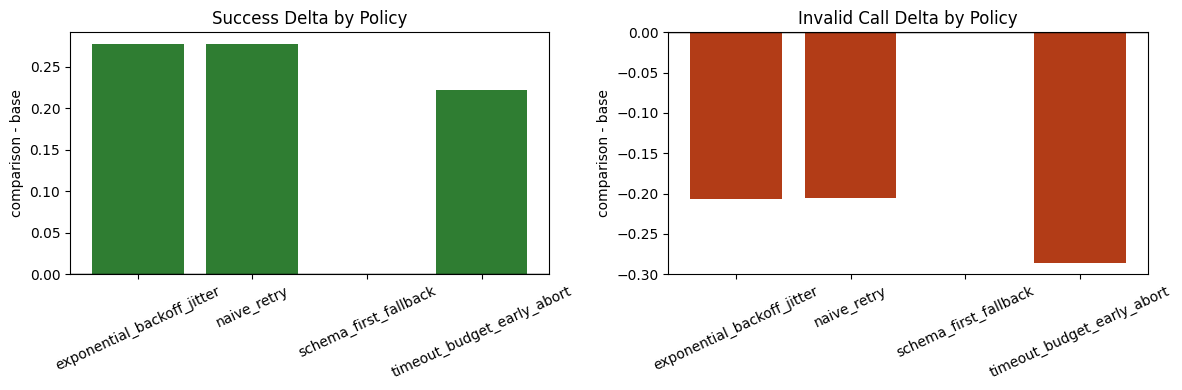

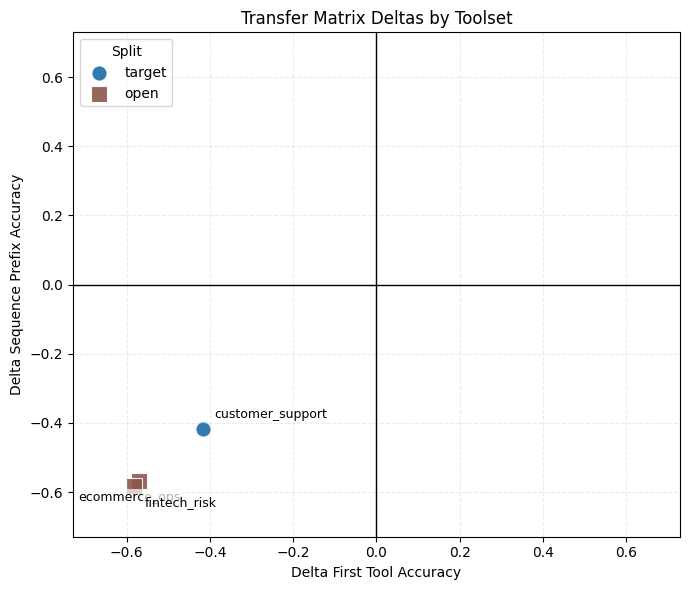

In [10]:
target_rows = delta_payload.get('target', {}).get('policies', [])
policies = [r.get('policy', 'unknown') for r in target_rows]
success_deltas = [float(r.get('delta', {}).get('task_success_rate', 0.0) or 0.0) for r in target_rows]
invalid_deltas = [float(r.get('delta', {}).get('invalid_tool_call_rate', 0.0) or 0.0) for r in target_rows]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(policies, success_deltas, color='#2f7d32')
axes[0].axhline(0.0, color='black', linewidth=1)
axes[0].set_title('Success Delta by Policy')
axes[0].set_ylabel('comparison - base')
axes[0].tick_params(axis='x', rotation=25)

axes[1].bar(policies, invalid_deltas, color='#b23c17')
axes[1].axhline(0.0, color='black', linewidth=1)
axes[1].set_title('Invalid Call Delta by Policy')
axes[1].set_ylabel('comparison - base')
axes[1].tick_params(axis='x', rotation=25)

plt.tight_layout()
plt.show()

rows = matrix_payload.get('rows', [])
first = [float(r.get('delta_first_tool_accuracy', 0.0)) for r in rows]
seq = [float(r.get('delta_sequence_prefix_accuracy', 0.0)) for r in rows]
labels = [str(r.get('toolset_id', 'toolset')) for r in rows]
splits = [str(r.get('split', 'open')) for r in rows]

split_color = {'target': '#1b6ca8', 'open': '#8c564b'}
split_marker = {'target': 'o', 'open': 's'}

plt.figure(figsize=(7, 6))
for split in ('target', 'open'):
    idx = [i for i, s in enumerate(splits) if s == split]
    if not idx:
        continue
    xs = [first[i] for i in idx]
    ys = [seq[i] for i in idx]
    plt.scatter(
        xs,
        ys,
        s=120,
        c=split_color[split],
        marker=split_marker[split],
        edgecolors='white',
        linewidths=0.8,
        alpha=0.9,
        label=split,
    )

for i, (x, y, label) in enumerate(zip(first, seq, labels)):
    offset_x = 8 if i % 2 == 0 else -44
    offset_y = 8 if i % 3 == 0 else -14
    plt.annotate(
        label,
        (x, y),
        textcoords='offset points',
        xytext=(offset_x, offset_y),
        fontsize=9,
        bbox={'boxstyle': 'round,pad=0.15', 'facecolor': 'white', 'alpha': 0.7, 'edgecolor': 'none'},
    )

max_abs = max([abs(v) for v in first + seq] + [0.01])
pad = max(0.01, max_abs * 0.25)
plt.xlim(-max_abs - pad, max_abs + pad)
plt.ylim(-max_abs - pad, max_abs + pad)
plt.axhline(0.0, color='black', linewidth=1)
plt.axvline(0.0, color='black', linewidth=1)
plt.grid(alpha=0.25, linestyle='--')
plt.xlabel('Delta First Tool Accuracy')
plt.ylabel('Delta Sequence Prefix Accuracy')
plt.title('Transfer Matrix Deltas by Toolset')
plt.legend(title='Split', loc='upper left')
plt.tight_layout()
plt.show()

## Outcome Checklist

This checklist marks whether the run demonstrates project outcomes with observable evidence.

In [11]:
artifacts_ok = all(p.exists() for p in paths)
matrix_rows = matrix_payload.get('rows', [])
max_abs_matrix_delta = max([abs(float(r.get('delta_first_tool_accuracy', 0.0))) for r in matrix_rows] + [abs(float(r.get('delta_sequence_prefix_accuracy', 0.0))) for r in matrix_rows] + [0.0])
matrix_signal_threshold = 0.01
matrix_signal_observed = max_abs_matrix_delta > matrix_signal_threshold
study_gate_present = bool(study_payload.get('verdict'))
delta_signal_observed = any(abs(v) > 1e-9 for v in success_deltas + invalid_deltas)

checks = [
    ('Artifacts generated', artifacts_ok),
    ('Delta signal observable', delta_signal_observed),
    (f'Matrix signal observable (>|{matrix_signal_threshold:.2f}|)', matrix_signal_observed),
    ('Study-gate verdict present', study_gate_present),
]

print('Outcome checks:')
for name, ok in checks:
    marker = 'PASS' if ok else 'FAIL'
    print(f'- {name}: {marker}')
print(f'- Max matrix absolute delta: {max_abs_matrix_delta:.4f}')

print('\nRun tag:', RUN_TAG)
print('Inspect run directory:', REPO_ROOT / 'runs')

Outcome checks:
- Artifacts generated: PASS
- Delta signal observable: PASS
- Matrix signal observable (>|0.01|): PASS
- Study-gate verdict present: PASS
- Max matrix absolute delta: 0.5833

Run tag: entrypoint-core-20260403-192104
Inspect run directory: /Users/aaliyan/aaliyan/tool-calling-reliability-benchmark/runs
